# 第一題
將資料集輸出直方圖及長條圖

In [72]:
# 掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 載入字型檔
font_path = '/content/drive/MyDrive/Noto_Sans_TC/static/NotoSansTC-Regular.ttf'

# 確認檔案存在
import os
if os.path.exists(font_path):
    print("字型檔案載入成功！")
else:
    print("找不到字型檔！請確認路徑是否正確。")
    print("你的字型實際路徑應該像這樣：/content/drive/MyDrive/資料夾名稱/NotoSansTC-Regular.ttf")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
字型檔案載入成功！


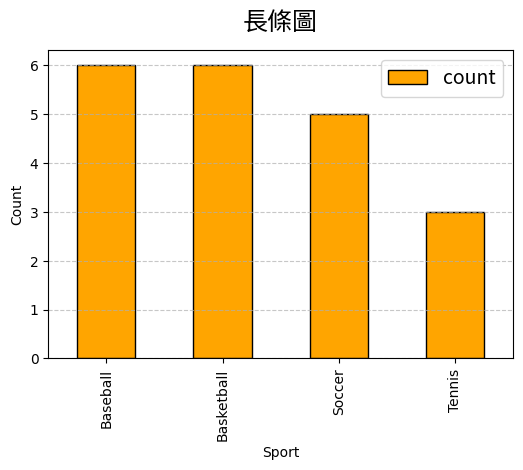

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.font_manager import FontProperties
font = FontProperties(fname=font_path, size=14)      # 載入字型
plt.rcParams['axes.unicode_minus'] = False           # 重要：解決負號顯示成方塊問題
plt.rcParams['font.sans-serif'] = [font.get_name()]  # 自動取得字型名稱

# 忽略 Matplotlib 的 findfont 警告
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


# 建立資料
data = {
    'Height': [160,172,151,183,166,169,175,158,179,164,178,156,172,181,159,177,163,185,168,154],
    'Sport': ['Baseball','Soccer','Baseball','Basketball','Soccer','Tennis','Basketball','Baseball',
              'Soccer','Basketball','Tennis','Baseball','Basketball','Tennis','Baseball','Soccer',
              'Basketball','Soccer','Basketball','Baseball']
}
df = pd.DataFrame(data)

# --- (1) 直方圖 Histogram ---
plt.figure(figsize=(6,4))
plt.hist(df['Height'], bins=6, color='skyblue', edgecolor='black')
plt.title('直方圖', fontproperties=font, fontsize=18, pad=15)
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- (2) 長條圖 Bar Chart ---
plt.figure(figsize=(6,4))
df['Sport'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.title('長條圖', fontproperties=font, fontsize=18, pad=15)
plt.xlabel('Sport')
plt.ylabel('Count')
plt.legend(prop=font)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 第二題
將資料集用 Python 做出 X,Y 的散佈圖

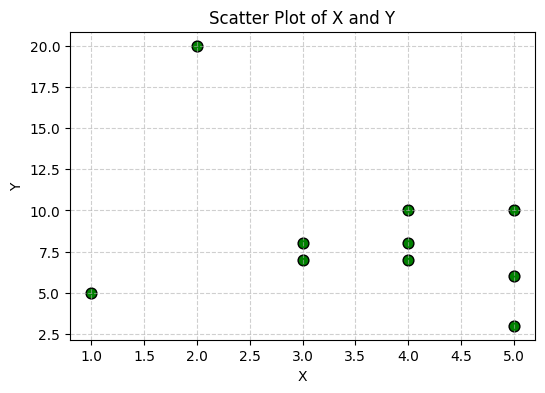

In [74]:
import matplotlib.pyplot as plt

X = [1, 2, 3, 4, 5, 5, 4, 4, 3, 5]
Y = [5, 20, 7, 8, 10, 6, 7, 10, 8, 3]

plt.figure(figsize=(6,4))
plt.scatter(X, Y, color='green', s=60, edgecolor='black')
plt.title('Scatter Plot of X and Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 第三題
假設你有三支股票 A,B,C 的每日收益率數據如下（單位：%）：
請撰寫 Python 程式碼來計算這些股票的 相關矩陣 (correlation matrix)，並使用 熱圖 (heatmap) 來視覺化相關係數。

          A         B         C
A  1.000000  0.972272 -0.844449
B  0.972272  1.000000 -0.909620
C -0.844449 -0.909620  1.000000


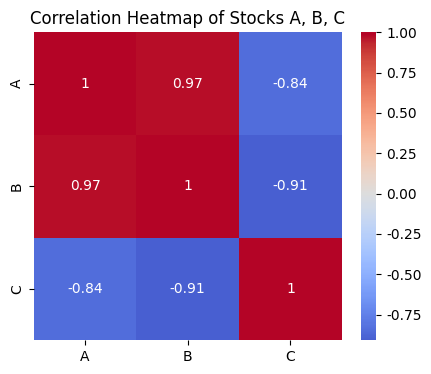

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 建立資料
data = {
    'A': [1.2, -0.3, 2.1, 1.0, -0.8],
    'B': [0.8, -0.6, 1.7, 0.7, -0.4],
    'C': [0.5, 0.9, -0.6, 0.4, 0.7]
}
df = pd.DataFrame(data)

# 計算相關矩陣
corr_matrix = df.corr()
print(corr_matrix)

# 繪製熱圖
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Stocks A, B, C')
plt.show()
